# Introduction in Machine Learning - WBAI056-2027
## Assignment 1

**Total points:** 15

**Starting date:** 10 September 2026

**Submission deadline:** 23:59, 7 October 2026

**Lecturer:** Dr. Andreea Sburlea

**Teaching Assistants:** Alex Todorov, Viki Simion, Cata Mihit, Iulia Bugan, Adriana Kobriger.

### General guidelines:

- The tasks are targeted at groups of three students. Please make sure that the workload is balanced: every student should contribute to the assignment.
- Please make use of the practical sessions to ask questions about the tasks.
- Provide a (short but comprehensive) explanation of what you are doing for each task.
- The plots should be standalone and understandable; so label axes, include a legend for colors, use an easily readable font size, etc.
- Refer to all plots, tables, code blocks, etc. in your report.
- For the report: you can use a Jupyter notebook or write a PDF in a word processor of your preference. Please include code as .py or .ipynb files as attachments in Brightspace.
- Each assignment has 3 parts. Every week you will receive another part. You can submit weekly the part of the assignment that you worked on that week or, by the deadline, the entire assignment.

## Part IIa - Linear vs. Nonlinear models
**Maximum obtainable points: 1**

For each of the statements below, indicate whether a linear model would be sufficient or whether a nonlinear model would be more appropriate. Briefly explain your reasoning.

- Predicting house prices where the relationship between income and house price appears approximately linear.
- Predicting house prices where house prices increase rapidly for low incomes but level off for high incomes.
- Predicting whether a wine belongs to one of three wine types when straight decision boundaries can separate the classes.
- Predicting whether a student passes an exam where the probability of passing depends strongly on an interaction between study hours and sleep hours.
- Predicting the value of y from x, where the relationship follows approximately y = x².

1. A linear model would be sufficient, the relationship between income and house prices is said to appear approximately linear so a straight line relationship could model the data well.
2. A nonlinear model would be better here because the relationship between income and prices is not linear, it is a steep line to start that curves off closer to the top of income.
3. The classes are separable by a straight decision boundary, meaning they are linearly separable, so a linear model would be sufficient.
4. While the relationship between study and sleep on passing most likely is not linear, a linear model could still be sufficient if we introduce a new feature of study*sleep. This way the model would remain linear in its parameters.
5. Using polynomial regression we can treat x² as a separate feature thus meaning a linear model would be sufficient.

## Part IIb - (Non)linear relationships
**Maximum obtainable points: 1**

Consider the following relationships between an input feature x and target y:

- y = 3x + 5
- y = x² + 2
- y = log(x)
- y = 4x₁ − 2x₂ + 7
- y = sin(x)

For each relationship, state whether it is linear or nonlinear with respect to the original features and give one reason for your answer.

1. The relationship is linear, having the form y = wx + b.
2. Nonlinear, the feature x is squared making the relationship curved instead of linear.
3. Nonlinear, the feature x has its logarithm taken, making the relationship curved.
4. Linear, the 2 features, x₁ and x₂, are added and in the first power so there is no curve.
5. Nonlinear, taking the sin wave of the function makes the relationship just that, a wave, so not linear.

## Part IIc - Feature Transformations and Nonlinear Relationships
**Maximum obtainable points: 3**

Use the california houses dataset available in scikit-learn ([https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)) and perform the following:

- Load the dataset in Python or Jupyter.
- Choose four to six features (up to you) that you think are best to predict house prices.
- Train a nonlinear regression model (for example, a decision tree) and decide if your results show whether the features you selected have a nonlinear relationship with the target or not. Compare your results with training the same model on the full set of features.
- Try a single transformation of your selected features (it is up to you if the transformation is linear or nonlinear) and evaluate if your new transformed features have a nonlinear relationship with the target.

# Nonlinearity in the California housing data

This notebook works through four tasks on scikit-learn's California housing dataset:

1. Load the data.
2. Choose four to six features that should predict house prices well.
3. Train a nonlinear model (a decision tree) on those features, decide whether the results show a nonlinear relationship with the target, and compare with the same model trained on all eight features.
4. Apply one transformation to the selected features and check whether the transformed features still have a nonlinear relationship with the target.

## Summary of results

I use six features: MedInc, HouseAge, AveRooms, AveOccup, Latitude and Longitude.

A tuned decision tree predicts unseen districts much better than linear regression on the same six features: a cross-validated $R^2$ of 0.724 against 0.599, and 0.730 against 0.582 on the test set. The tree wins in all five folds. The relationship between these features and house value is nonlinear. Most of the nonlinearity is location, which rises and falls with latitude and longitude and only makes sense as a combination of the two. AveOccup, AveRooms and HouseAge add curves and jumps, and the cap on house values limits the top end. Income on its own is close to linear.

On all eight features the same tree scores 0.716 (CV) and 0.727 (test), so it does no better than with six. AveBedrms and Population add nothing a tree can use, and the gap between the tree and linear regression is about the same size.

Taking the log of AveRooms and AveOccup leaves the tree's predictions unchanged (section 7 explains why) and raises linear regression to 0.653 (CV) and 0.640 (test). That closes about 43% of the gap, but the tree still wins in every fold, so the transformed features still have a nonlinear relationship with the target. What is left is mostly location, which no transformation of one feature at a time can straighten.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import r2_score, mean_squared_error

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_STATE = 42
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

scikit-learn 1.8.0 | pandas 3.0.2 | numpy 2.4.4


## 1. Load the data

Each row is a census block group from the 1990 US census, which I will call a district. A district typically has 600 to 3,000 people. The target, `MedHouseVal`, is the median house value in the district in units of 100,000 US dollars.

| Feature | Meaning |
|---|---|
| MedInc | median income in the district (units of 10,000 USD) |
| HouseAge | median age of the houses (years) |
| AveRooms | average number of rooms per household |
| AveBedrms | average number of bedrooms per household |
| Population | number of people living in the district |
| AveOccup | average number of people per household |
| Latitude | latitude of the district (degrees north) |
| Longitude | longitude of the district (degrees east, so negative in California) |

In [2]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
df = housing.frame

print(f"{X.shape[0]:,} districts, {X.shape[1]} features, target = {housing.target_names[0]}")
df.head()

20,640 districts, 8 features, target = MedHouseVal


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.325,41.000,6.984,1.024,322.000,2.556,37.880,-122.230,4.526
1,8.301,21.000,6.238,0.972,2401.000,2.110,37.860,-122.220,3.585
2,7.257,52.000,8.288,1.073,496.000,2.802,37.850,-122.240,3.521
3,5.643,52.000,5.817,1.073,558.000,2.548,37.850,-122.250,3.413
4,3.846,52.000,6.282,1.081,565.000,2.181,37.850,-122.250,3.422


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
HouseAge,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
AveRooms,20640.000,5.429,2.474,0.846,4.441,5.229,6.052,141.909
AveBedrms,20640.000,1.097,0.474,0.333,1.006,1.049,1.100,34.067
Population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
AveOccup,20640.000,3.071,10.386,0.692,2.430,2.818,3.282,1243.333
Latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
Longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
MedHouseVal,20640.000,2.069,1.154,0.150,1.196,1.797,2.647,5.000


In [4]:
n_capped = (y >= 5.0).sum()
print(f"Median AveOccup: {X['AveOccup'].median():.2f}   maximum: {X['AveOccup'].max():,.0f}")
print(f"Median AveRooms: {X['AveRooms'].median():.2f}   maximum: {X['AveRooms'].max():,.0f}")
print(f"Districts at the 5.00001 cap: {n_capped} ({n_capped / len(y):.1%})")
print(f"Districts at HouseAge = 52 (also a top code): {(X['HouseAge'] == 52).sum()}")

Median AveOccup: 2.82   maximum: 1,243
Median AveRooms: 5.23   maximum: 142
Districts at the 5.00001 cap: 992 (4.8%)
Districts at HouseAge = 52 (also a top code): 1273


Two details matter later.

The household averages have extreme tails. AveOccup has a median of 2.8 people per household but a maximum of 1,243, and AveRooms reaches 142. These values come from districts with very few households (the scikit-learn documentation mentions vacation resorts with many empty houses). A handful of such districts can pull a least-squares line a long way.

Both the target and HouseAge are top-coded. Every house value above 500,000 dollars is recorded as 500,001, so 992 districts (4.8%) sit at exactly 5.00001. HouseAge stops at 52 in the same way. A straight line cannot flatten out at a cap, so the cap is a source of nonlinearity in its own right.

## 2. Train/test split

I set aside 20% of the districts as a test set before looking at any relationships. Feature selection and hyperparameter tuning only use the training set. Every cross-validation score in this notebook comes from the same five folds of the training set, so all models are compared on identical data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Training set: {len(X_train):,} districts | test set: {len(X_test):,} districts")

Training set: 16,512 districts | test set: 4,128 districts


## 3. Choosing the features

I look at three measures of how strongly each feature is related to the target, all computed on the training set.

Pearson's $r$ measures linear association. Spearman's $\rho$ is Pearson's $r$ computed on ranks, so it measures any monotonic association and is not pulled around by extreme values. Mutual information measures dependence of any shape:

$$I(X;Y)=\iint p(x,y)\,\ln\frac{p(x,y)}{p(x)\,p(y)}\,dx\,dy$$

It is zero only when $X$ and $Y$ are independent, whatever the shape of the relationship. scikit-learn estimates it with a nearest-neighbour method.

In [6]:
relevance = pd.DataFrame({
    "Pearson r": X_train.corrwith(y_train),
    "Spearman rho": X_train.corrwith(y_train, method="spearman"),
    "Mutual information": mutual_info_regression(X_train, y_train, random_state=RANDOM_STATE),
}).sort_values("Mutual information", ascending=False)

relevance

,Pearson r,Spearman rho,Mutual information
Longitude,-0.046,-0.072,0.390
MedInc,0.691,0.678,0.386
Latitude,-0.143,-0.163,0.362
AveRooms,0.158,0.261,0.101
AveOccup,-0.022,-0.258,0.076
HouseAge,0.104,0.072,0.036
Population,-0.026,0.004,0.027
AveBedrms,-0.051,-0.130,0.025


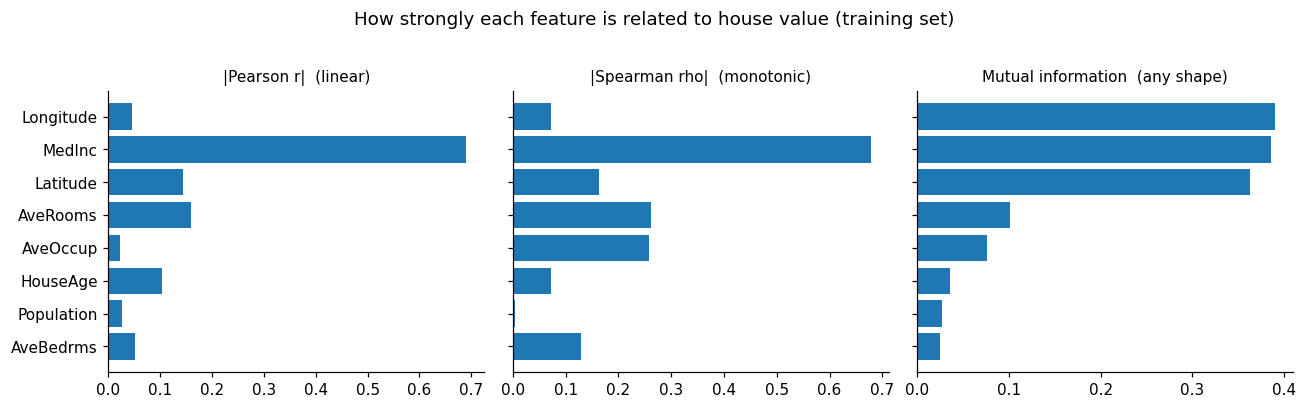

In [7]:
order = relevance.index[::-1]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
panels = [("Pearson r", "|Pearson r|  (linear)"),
          ("Spearman rho", "|Spearman rho|  (monotonic)"),
          ("Mutual information", "Mutual information  (any shape)")]
for ax, (col, title) in zip(axes, panels):
    ax.barh(order, relevance.loc[order, col].abs(), color="tab:blue")
    ax.set_title(title, fontsize=10)
fig.suptitle("How strongly each feature is related to house value (training set)", y=1.02)
plt.tight_layout()
plt.show()

Two pairs of features are strongly correlated with each other. When that happens, one feature of the pair can be redundant:

In [8]:
corr = X_train.corr()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = upper.stack().rename("r").reset_index()
pairs.columns = ["feature 1", "feature 2", "r"]
pairs[pairs["r"].abs() > 0.5].sort_values("r", key=np.abs, ascending=False)

,feature 1,feature 2,r
55,Latitude,Longitude,-0.924
19,AveRooms,AveBedrms,0.836


**Selected features: MedInc, HouseAge, AveRooms, AveOccup, Latitude, Longitude.**

These are the top six by mutual information, and each has a clear economic reason to matter. Income sets what buyers in the district can pay. Latitude and longitude place the district relative to the coast and to the San Francisco and Los Angeles areas. AveRooms measures how big the homes are, AveOccup measures crowding, and HouseAge describes the housing stock.

I drop AveBedrms and Population. AveBedrms has a correlation of 0.84 with AveRooms, so it mostly repeats information I already have, and it has the lowest mutual information of the eight. Population counts the people in the district, which says more about where the census drew the boundary than about the houses, and it has the second-lowest mutual information. Latitude and longitude are also highly correlated ($r=-0.92$, because California runs from north-west to south-east), but I keep both: a location needs two coordinates, and each has high mutual information on its own.

The table already hints at the answer to the main question. Longitude has the highest mutual information of all eight features but a Pearson correlation of only $-0.05$. AveOccup has almost no linear correlation ($-0.02$) but a Spearman correlation of $-0.26$ and clearly positive mutual information. A feature can only be informative and linearly uncorrelated at the same time if its relationship with the target is not a straight line.

In [9]:
dropped = ["AveBedrms", "Population"]
all_features = list(X.columns)
selected = [f for f in all_features if f not in dropped]

print("Selected:", selected)
print("Dropped: ", dropped)

Selected: ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude']
Dropped:  ['AveBedrms', 'Population']


## 4. How I decide whether a relationship is nonlinear

I fit two models on the same features and compare them on data they have not seen.

Linear regression can only represent a weighted sum of the features:

$$\hat y = \beta_0 + \sum_{j=1}^{p}\beta_j x_j$$

A regression tree splits the feature space into rectangles $R_1,\dots,R_M$ and predicts the average training target inside each one:

$$\hat y(x) = \sum_{m=1}^{M} c_m\,\mathbf{1}\{x\in R_m\},\qquad c_m=\frac{1}{|R_m|}\sum_{x_i\in R_m} y_i$$

A tree can represent curves, thresholds, effects that go up and then down, and interactions between features, although only as step functions. So the test is this: if the tree predicts held-out data clearly better than the linear model, the extra accuracy must come from structure that a weighted sum cannot express, which means the relationship is nonlinear. I measure accuracy with

$$R^2 = 1-\frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2},\qquad \text{RMSE}=\sqrt{\frac{1}{n}\sum_i (y_i-\hat y_i)^2}$$

on the five cross-validation folds and on the test set. I only treat a gap as real if it is much larger than the variation between folds and appears in every fold.

The test only works in one direction. If the tree lost, that would not prove the relationship is linear, because a step function is an inefficient way to draw a straight line.

An unpruned tree memorises the training data, so I tune `max_depth` and `min_samples_leaf` by 5-fold cross-validation on the training set. The helper functions below do the tuning and the scoring, and I reuse them for every comparison in the notebook.

In [10]:
PARAM_GRID = {"max_depth": [4, 6, 8, 10, 12, 14, 16, None],
              "min_samples_leaf": [1, 5, 10, 20, 40, 80]}


def tuned_tree(X_tr, y_tr):
    # Choose max_depth and min_samples_leaf by 5-fold CV on the training data only.
    search = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), PARAM_GRID,
                          cv=cv, scoring="r2", n_jobs=-1)
    search.fit(X_tr, y_tr)
    return search.best_estimator_, search.best_params_


def compare_models(features, X_tr=None, X_te=None):
    # Fit linear regression and a tuned tree on the same features and score both the same way.
    X_tr = X_train if X_tr is None else X_tr
    X_te = X_test if X_te is None else X_te
    tree, best_params = tuned_tree(X_tr[features], y_train)
    models = {"Linear regression": LinearRegression(), "Decision tree": tree}
    rows, folds = {}, {}
    for name, model in models.items():
        fold_r2 = cross_val_score(model, X_tr[features], y_train, cv=cv, scoring="r2")
        model.fit(X_tr[features], y_train)
        pred = model.predict(X_te[features])
        folds[name] = fold_r2
        rows[name] = {
            "CV R² mean": fold_r2.mean(),
            "CV R² sd": fold_r2.std(),
            "Train R²": r2_score(y_train, model.predict(X_tr[features])),
            "Test R²": r2_score(y_test, pred),
            "Test RMSE (USD)": np.sqrt(mean_squared_error(y_test, pred)) * 100_000,
        }
    table = pd.DataFrame(rows).T
    table["Test RMSE (USD)"] = table["Test RMSE (USD)"].round(-2).astype(int)
    folds = pd.DataFrame(folds, index=[f"fold {i}" for i in range(1, 6)])
    folds["Tree minus linear"] = folds["Decision tree"] - folds["Linear regression"]
    return {"table": table, "folds": folds, "models": models, "best_params": best_params}


def one_feature_check(feature_sets, X_tr):
    # Linear regression vs a tree on one feature (or a small group) at a time, 5-fold CV R².
    rows = {}
    for label, cols in feature_sets.items():
        lin = cross_val_score(LinearRegression(), X_tr[cols], y_train, cv=cv, scoring="r2").mean()
        search = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                              {"min_samples_leaf": [10, 25, 50, 100, 200, 400]}, cv=cv, scoring="r2")
        tree = search.fit(X_tr[cols], y_train).best_score_
        rows[label] = {"Linear CV R²": lin, "Tree CV R²": tree, "Gap": tree - lin}
    return pd.DataFrame(rows).T

## 5. Decision tree on the selected features

First, why the tree needs tuning:

In [11]:
unpruned = DecisionTreeRegressor(random_state=RANDOM_STATE)
unpruned_cv = cross_val_score(unpruned, X_train[selected], y_train, cv=cv, scoring="r2").mean()
unpruned.fit(X_train[selected], y_train)
print(f"Unpruned tree: train R² = {unpruned.score(X_train[selected], y_train):.3f}, CV R² = {unpruned_cv:.3f}, "
      f"{unpruned.get_n_leaves():,} leaves")

Unpruned tree: train R² = 1.000, CV R² = 0.616, 15,882 leaves


The unpruned tree fits the training data perfectly and generalises much worse, so from here on the tree is tuned. Now the main comparison:

In [12]:
sel = compare_models(selected)
print("Tree hyperparameters chosen by CV:", sel["best_params"])
sel["table"]

Tree hyperparameters chosen by CV: {'max_depth': 14, 'min_samples_leaf': 20}


,CV R² mean,CV R² sd,Train R²,Test R²,Test RMSE (USD)
Linear regression,0.599,0.012,0.600,0.582,74000
Decision tree,0.724,0.017,0.807,0.730,59500


In [13]:
sel["folds"]

,Linear regression,Decision tree,Tree minus linear
fold 1,0.596,0.710,0.114
fold 2,0.599,0.747,0.149
fold 3,0.621,0.733,0.112
fold 4,0.587,0.698,0.111
fold 5,0.591,0.730,0.138


The tuned tree reaches a cross-validated $R^2$ of 0.724 against 0.599 for linear regression. On the test set the gap is a little larger, 0.730 against 0.582, and the typical error (RMSE) falls from about 74,000 to about 59,500 dollars.

The fold table shows the gap is not noise. The tree wins in all five folds, by between 0.11 and 0.15, while each model's own score only varies by 0.01 to 0.02 between folds. The tree does overfit somewhat (train $R^2$ 0.81 against 0.72 in CV), but that only makes it look worse on unseen data, so it does not weaken the conclusion.

There is also a simple sign of misfit in the linear predictions:

In [14]:
lin_pred = sel["models"]["Linear regression"].predict(X_test[selected])
tree_pred = sel["models"]["Decision tree"].predict(X_test[selected])
print(f"Linear regression: {(lin_pred > 5.00001).sum()} test predictions above the 5.00001 cap, "
      f"{(lin_pred < 0).sum()} below zero (range {lin_pred.min():.2f} to {lin_pred.max():.2f})")
print(f"Decision tree:     predictions range from {tree_pred.min():.2f} to {tree_pred.max():.2f}")

Linear regression: 35 test predictions above the 5.00001 cap, 19 below zero (range -1.08 to 6.83)
Decision tree:     predictions range from 0.49 to 5.00


The linear model predicts values the data cannot contain. The tree predicts averages of real training values, so it stays inside the observed range and respects the cap automatically.

### Which features are nonlinear?

The comparison above says the six features together have a nonlinear relationship with the target. To see where it comes from, I repeat the comparison one feature at a time, plus latitude and longitude as a pair. (The single-feature trees are tuned on `min_samples_leaf` only.)

In [15]:
feature_sets = {f: [f] for f in selected}
feature_sets["Latitude + Longitude"] = ["Latitude", "Longitude"]
per_feature = one_feature_check(feature_sets, X_train)
per_feature

,Linear CV R²,Tree CV R²,Gap
MedInc,0.477,0.488,0.012
HouseAge,0.010,0.027,0.016
AveRooms,0.023,0.148,0.126
AveOccup,-0.001,0.079,0.080
Latitude,0.020,0.245,0.225
Longitude,0.002,0.297,0.295
Latitude + Longitude,0.239,0.734,0.494


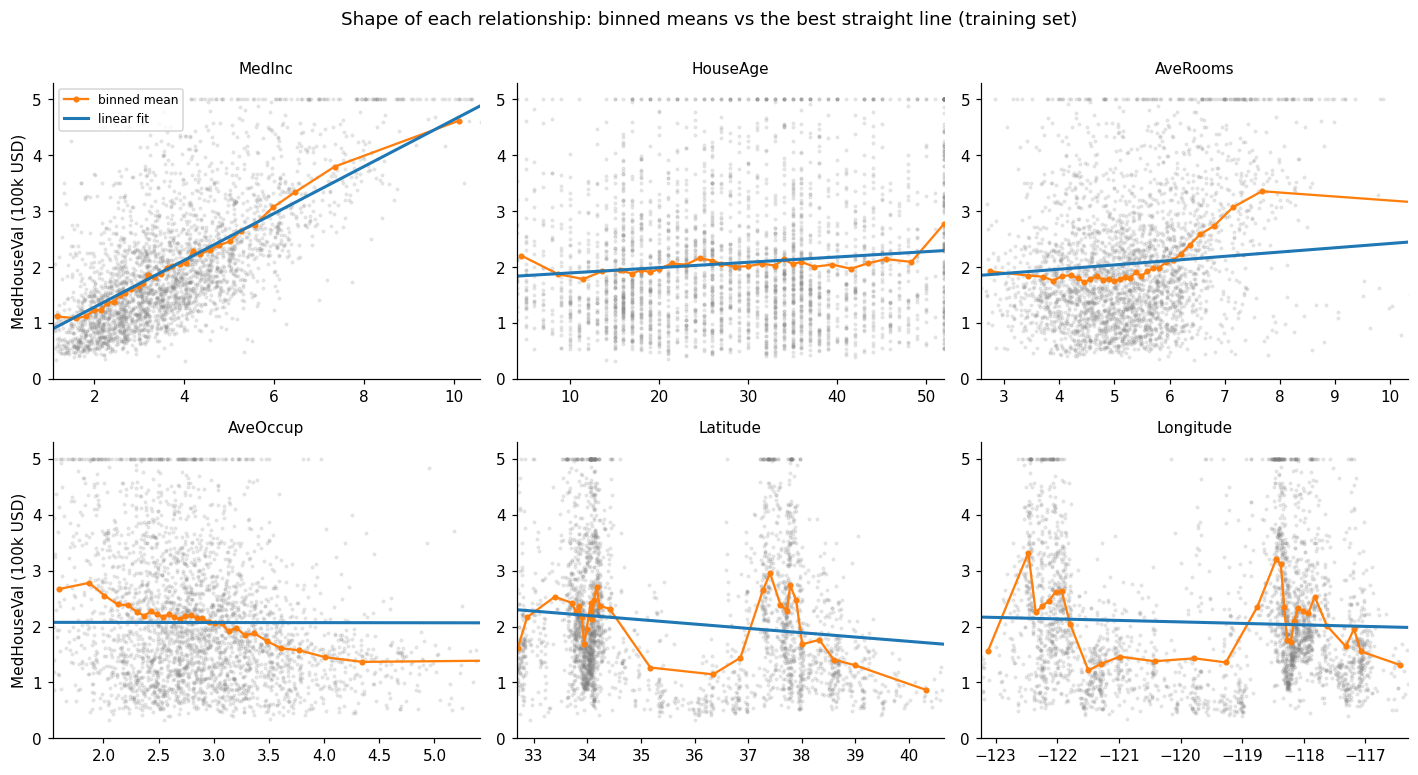

In [16]:
def binned_means(x, y, bins=30):
    groups = pd.qcut(x, q=bins, duplicates="drop")
    means = pd.DataFrame({"x": x, "y": y}).groupby(groups, observed=True).mean()
    return means["x"], means["y"]


def shape_plot(ax, x, y, title, sample=3000):
    # Grey dots: a random sample of districts. Orange: mean house value in 30 equal-count bins.
    # Blue: least-squares line fitted to all training districts. x-axis shows the 1st-99th percentile.
    rng = np.random.default_rng(0)
    idx = rng.choice(len(x), size=min(sample, len(x)), replace=False)
    ax.scatter(x.iloc[idx], y.iloc[idx], s=3, alpha=0.15, color="grey")
    bx, by = binned_means(x, y)
    ax.plot(bx, by, "o-", color="tab:orange", ms=3, lw=1.5, label="binned mean")
    line = LinearRegression().fit(x.to_frame(), y)
    lo, hi = x.quantile(0.01), x.quantile(0.99)
    grid = pd.DataFrame({x.name: np.linspace(lo, hi, 100)})
    ax.plot(grid[x.name], line.predict(grid), color="tab:blue", lw=2, label="linear fit")
    ax.set_xlim(lo, hi)
    ax.set_ylim(0, 5.3)
    ax.set_title(title, fontsize=10)


fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, f in zip(axes.ravel(), selected):
    shape_plot(ax, X_train[f], y_train, f)
axes[0, 0].legend(loc="upper left", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("MedHouseVal (100k USD)")
fig.suptitle("Shape of each relationship: binned means vs the best straight line (training set)", y=1.0)
plt.tight_layout()
plt.show()

The table and the plots tell the same story.

MedInc is close to linear. A straight line explains almost as much as the tree (0.477 against 0.488), and the binned means climb steadily. The small gap comes mostly from the top end, where the curve flattens because house values cannot rise above the cap.

Location is strongly nonlinear. Latitude on its own explains 0.02 with a line but 0.25 with a tree, and longitude 0.002 against 0.30. The binned means go up and down: prices peak around 34°N (Los Angeles) and 37.5 to 37.8°N (San Francisco Bay Area), and fall in the Central Valley in between and in the north. Together the coordinates reach 0.73 with a tree but only 0.24 with a line. A linear model can only tilt one plane across the map, while the expensive districts sit in patches along the coast, so location is an interaction between the two coordinates as well as a curve in each. (A tree on the coordinates alone does about as well as the six-feature tree, because neighbouring districts have similar prices and similar incomes, so a fine grid of map cells carries much of the same information.)

AveOccup and AveRooms are nonlinear too. The binned means for AveOccup fall from about 2.8 at 2 people per household to about 1.4 at 4 people and then level off. The least-squares line is flat because a few districts with enormous values pull it level, so it explains nothing (CV $R^2$ of $-0.001$) against 0.08 for the tree. AveRooms is flat, even dipping slightly, up to about 5.5 rooms per household and then rises steeply (0.02 against 0.15).

HouseAge is weak either way (0.01 against 0.03). Its binned means are flat until the last bin, where the districts at the top code of 52 years are worth clearly more.

Where the linear model goes wrong is easiest to see on a map of its test-set errors:

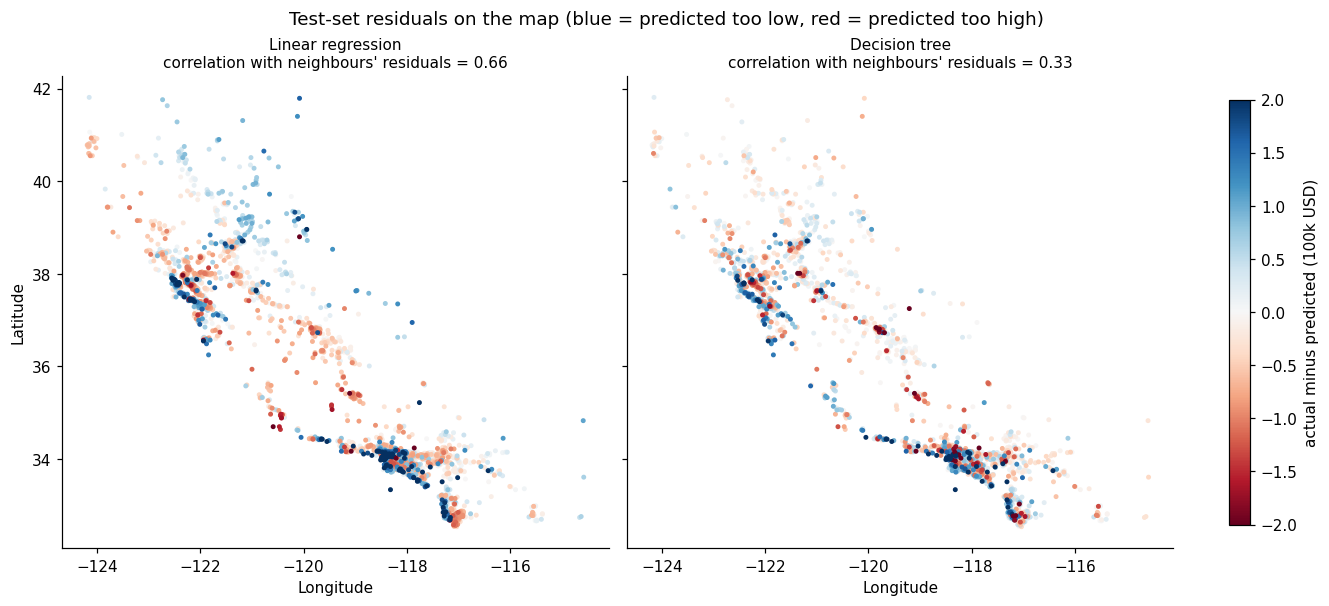

In [17]:
coords = X_test[["Latitude", "Longitude"]].to_numpy()
neighbours = NearestNeighbors(n_neighbors=11).fit(coords).kneighbors(coords, return_distance=False)[:, 1:]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), sharex=True, sharey=True, constrained_layout=True)
for ax, name in zip(axes, ["Linear regression", "Decision tree"]):
    resid = (y_test - sel["models"][name].predict(X_test[selected])).to_numpy()
    spatial_r = np.corrcoef(resid, resid[neighbours].mean(axis=1))[0, 1]
    order = np.argsort(np.abs(resid))
    sc = ax.scatter(X_test["Longitude"].to_numpy()[order], X_test["Latitude"].to_numpy()[order],
                    c=resid[order], cmap="RdBu", vmin=-2, vmax=2, s=5)
    ax.set_title(f"{name}\ncorrelation with neighbours' residuals = {spatial_r:.2f}", fontsize=10)
    ax.set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(sc, ax=axes, label="actual minus predicted (100k USD)", shrink=0.9)
fig.suptitle("Test-set residuals on the map (blue = predicted too low, red = predicted too high)")
plt.show()

The linear model's errors form clear geographic clusters. It predicts too low around San Francisco Bay and along the Los Angeles coast, and too high in much of the Central Valley and the far north. A district's residual has a correlation of 0.66 with the average residual of its 10 nearest test-set neighbours, which means the errors are systematic, not random. For the tree that correlation falls to 0.33. Errors that depend on where a district is are exactly what a model with the wrong functional form for location leaves behind.

**Conclusion for task 3:** yes, the results show that the selected features have a nonlinear relationship with house value. The tree beats linear regression by 0.125 $R^2$ in cross-validation and 0.15 on the test set, and it wins in every fold. The nonlinearity comes mainly from location (a non-monotonic surface over latitude and longitude), with smaller contributions from AveOccup, AveRooms and HouseAge and from the cap on the target. Income itself is close to linear.

## 6. The same model on all eight features

I now run exactly the same procedure (same folds, same tuning grid, same test set) on all eight features.

In [18]:
full = compare_models(all_features)
print("Tree hyperparameters chosen by CV:", full["best_params"])
full["table"]

Tree hyperparameters chosen by CV: {'max_depth': 14, 'min_samples_leaf': 20}


,CV R² mean,CV R² sd,Train R²,Test R²,Test RMSE (USD)
Linear regression,0.611,0.012,0.613,0.576,74600
Decision tree,0.716,0.016,0.808,0.727,59900


In [19]:
comparison = pd.concat({"6 selected features": sel["table"], "All 8 features": full["table"]})
comparison

CV R² mean  CV R² sd  Train R²  \
6 selected features Linear regression       0.599     0.012     0.600   
                    Decision tree           0.724     0.017     0.807   
All 8 features      Linear regression       0.611     0.012     0.613   
                    Decision tree           0.716     0.016     0.808   

                                       Test R²  Test RMSE (USD)  
6 selected features Linear regression    0.582            74000  
                    Decision tree        0.730            59500  
All 8 features      Linear regression    0.576            74600  
                    Decision tree        0.727            59900

In [20]:
imp = permutation_importance(full["models"]["Decision tree"], X_test[all_features], y_test,
                             n_repeats=10, random_state=RANDOM_STATE, scoring="r2")
importance = pd.DataFrame({"Drop in test R² when shuffled": imp.importances_mean,
                           "sd over 10 shuffles": imp.importances_std},
                          index=all_features).sort_values("Drop in test R² when shuffled", ascending=False)
importance

,Drop in test R² when shuffled,sd over 10 shuffles
MedInc,0.913,0.023
Latitude,0.306,0.006
Longitude,0.226,0.009
AveOccup,0.224,0.010
HouseAge,0.077,0.004
AveRooms,0.039,0.003
AveBedrms,0.010,0.002
Population,0.007,0.001


With all eight features, cross-validation picks the same tree settings (`max_depth` 14, `min_samples_leaf` 20). The tree scores 0.716 in CV and 0.727 on the test set, slightly below the six-feature tree (0.724 and 0.730). These differences are smaller than the variation between folds, so the fair reading is that AveBedrms and Population add nothing the tree can use. Permutation importance agrees: shuffling AveBedrms or Population lowers the test $R^2$ by only about 0.01, against 0.91 for MedInc and 0.2 to 0.3 for latitude, longitude and AveOccup. Dropping them costs nothing and gives a simpler model.

Linear regression gains a little in cross-validation from the two extra features (0.611 against 0.599) but does slightly worse on the test set (0.576 against 0.582), so for the linear model the difference is small as well.

The gap between the tree and linear regression is about the same size with all eight features (0.105 in CV, 0.15 on the test set) as with six. The finding that the relationship is nonlinear does not depend on which features I picked.

## 7. One transformation: the log of the household averages

The transformation I use is the natural logarithm, applied to AveRooms and AveOccup:

$$\tilde x = \ln x$$

The other four selected features pass through unchanged. The reasons for this choice:

- AveRooms and AveOccup are ratios with enormous right tails (skewness 18.6 and 88 in the training set, shown below). Their binned means in section 5 change steeply over a narrow range and then flatten, which is the kind of curve a log straightens. The log also pulls the few extreme districts back towards the rest, so they stop dominating the least-squares fit.
- MedInc and HouseAge are not log-shaped. MedInc is already close to linear and HouseAge is flat with a jump at 52. The check below confirms that taking their log makes the linear fit worse.
- Latitude and longitude are coordinates. The log of a longitude is not even defined (it is negative), and more importantly their relationship with price goes up and down. No increasing transformation can turn a curve that rises and falls into a straight line.

**What each model should do.** Take any strictly increasing function $g$, such as $\ln$. The split $x_j \le t$ sends exactly the same training points to the left as the split $g(x_j) \le g(t)$, because $g$ keeps the values in the same order. Every candidate split therefore divides the training data the same way and gets the same score, so the tree ends up with the same partition of the training data and the same leaf values. (New points could in principle be routed differently, because the tree puts each threshold halfway between two training values, and halfway in $\ln x$ is not halfway in $x$. Below, not a single test prediction changes.) Linear regression does change, because $\beta_j \ln x_j$ is a different function of $x_j$ than $\beta_j x_j$. So any change in the gap between the two models comes from the linear side only, and it measures how much of the nonlinearity was log-shaped.

This is also why I did not pick a linear transformation such as standardising, $\tilde x = (x-\mu)/\sigma$. Since $\beta_j(a x_j + b) = (a\beta_j)\,x_j + b\beta_j$, a linear model on $a x_j + b$ can represent exactly the same functions as on $x_j$, and its $R^2$ would not move at all. A linear transformation cannot make a nonlinear relationship linear.

In [21]:
to_log = ["AveRooms", "AveOccup"]
X_log = X.copy()
X_log[to_log] = np.log(X_log[to_log])
X_log_train, X_log_test = X_log.loc[X_train.index], X_log.loc[X_test.index]

pd.DataFrame({"Skewness before": X_train[to_log].skew(),
              "Skewness after log": X_log_train[to_log].skew()})

,Skewness before,Skewness after log
AveRooms,18.607,0.827
AveOccup,88.053,2.353


The log has no fitted parameters, so applying it before the split does not leak any information from the test set.

First the one-feature check, before and after the log, for all four selected features that are positive:

In [22]:
positive = ["MedInc", "HouseAge", "AveRooms", "AveOccup"]
raw = one_feature_check({f: [f] for f in positive}, X_train)
logged = one_feature_check({f: [f] for f in positive}, np.log(X_train[positive]))

pd.DataFrame({"Linear CV R², x": raw["Linear CV R²"],
              "Linear CV R², ln x": logged["Linear CV R²"],
              "Tree CV R², x": raw["Tree CV R²"],
              "Tree CV R², ln x": logged["Tree CV R²"]})

,"Linear CV R², x","Linear CV R², ln x","Tree CV R², x","Tree CV R², ln x"
MedInc,0.477,0.427,0.488,0.488
HouseAge,0.010,0.005,0.027,0.027
AveRooms,0.023,0.057,0.148,0.148
AveOccup,-0.001,0.063,0.079,0.079


As expected, the tree columns are identical. For linear regression the log helps exactly the two features I chose: AveRooms goes from 0.023 to 0.057 and AveOccup from about zero ($-0.001$) to 0.063. For MedInc and HouseAge it makes the fit worse (0.477 to 0.427 and 0.010 to 0.005), which is why I leave them alone.

The plots show the same thing. The top row is the raw features from section 5, the bottom row is after the log:

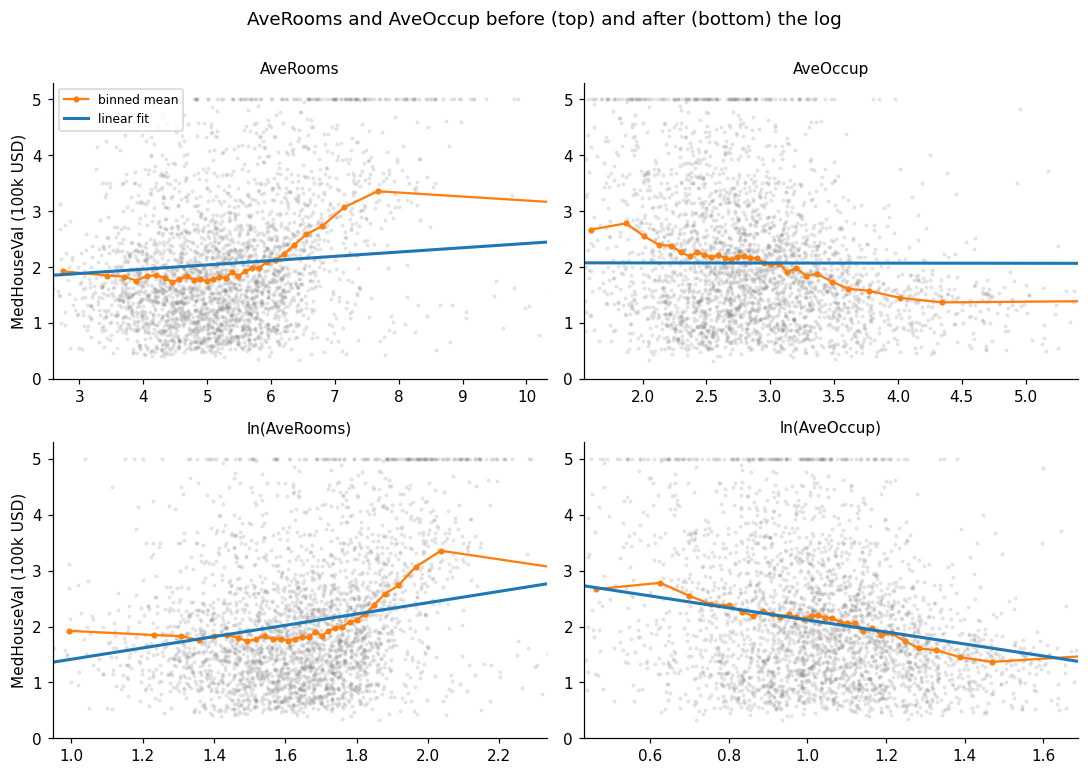

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for col, f in enumerate(to_log):
    shape_plot(axes[0, col], X_train[f], y_train, f)
    shape_plot(axes[1, col], X_log_train[f].rename(f"ln {f}"), y_train, f"ln({f})")
axes[0, 0].legend(loc="upper left", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("MedHouseVal (100k USD)")
fig.suptitle("AveRooms and AveOccup before (top) and after (bottom) the log", y=1.0)
plt.tight_layout()
plt.show()

After the log, the linear fit for AveOccup follows the binned means closely, so this relationship is now nearly linear (linear 0.063 against 0.079 for the tree). For AveRooms the line now has a clear slope, but the binned means still dip and then rise, so this one is still curved (0.057 against 0.148).

Now the full comparison on the six transformed features, with the same procedure as before:

In [24]:
logm = compare_models(selected, X_log_train, X_log_test)
print("Tree hyperparameters chosen by CV:", logm["best_params"])
logm["table"]

Tree hyperparameters chosen by CV: {'max_depth': 14, 'min_samples_leaf': 20}


,CV R² mean,CV R² sd,Train R²,Test R²,Test RMSE (USD)
Linear regression,0.653,0.013,0.653,0.640,68700
Decision tree,0.724,0.017,0.807,0.730,59500


In [25]:
logm["folds"]

,Linear regression,Decision tree,Tree minus linear
fold 1,0.648,0.710,0.063
fold 2,0.638,0.747,0.109
fold 3,0.677,0.733,0.055
fold 4,0.646,0.698,0.052
fold 5,0.654,0.730,0.076


In [26]:
identical = np.array_equal(sel["models"]["Decision tree"].predict(X_test[selected]),
                           logm["models"]["Decision tree"].predict(X_log_test[selected]))
print("Tree test predictions identical before and after the log:", identical)

gap_before = sel["table"].loc["Decision tree", "CV R² mean"] - sel["table"].loc["Linear regression", "CV R² mean"]
gap_after = logm["table"].loc["Decision tree", "CV R² mean"] - logm["table"].loc["Linear regression", "CV R² mean"]
print(f"CV gap (tree minus linear): {gap_before:.3f} before the log, {gap_after:.3f} after "
      f"-> {1 - gap_after / gap_before:.0%} of the gap removed")

Tree test predictions identical before and after the log: True
CV gap (tree minus linear): 0.125 before the log, 0.071 after -> 43% of the gap removed


The tree's scores are unchanged, and its test predictions are identical to those of the tree trained on the raw features, as the argument above says they must be. Linear regression improves from 0.599 to 0.653 in CV and from 0.582 to 0.640 on the test set, and its RMSE falls from about 74,000 to about 68,700 dollars.

So the log removed part of the nonlinearity: the gap in CV shrinks from 0.125 to 0.071, about 43% of the original. It did not remove all of it. The tree still beats linear regression in every fold, by 0.05 to 0.11, which is again well outside the fold-to-fold variation.

**Conclusion for task 4:** the transformed features still have a nonlinear relationship with the target. The log made AveOccup close to linear and helped AveRooms, but the largest source of nonlinearity, location, is untouched by any transformation of one feature at a time. Latitude and longitude still show a linear $R^2$ of 0.24 against 0.73 for a tree, and the cap on the target still limits what a straight line can do. Closing that part of the gap would need a feature that describes location directly, such as distance to the coast or to the nearest large city.

## 8. Summary

In [27]:
runs = {"6 selected": sel, "All 8": full, "6 selected, log(AveRooms), log(AveOccup)": logm}
summary = pd.DataFrame({
    label: {
        "Linear CV R²": r["table"].loc["Linear regression", "CV R² mean"],
        "Tree CV R²": r["table"].loc["Decision tree", "CV R² mean"],
        "Gap (CV)": r["table"].loc["Decision tree", "CV R² mean"] - r["table"].loc["Linear regression", "CV R² mean"],
        "Linear test R²": r["table"].loc["Linear regression", "Test R²"],
        "Tree test R²": r["table"].loc["Decision tree", "Test R²"],
        "Gap (test)": r["table"].loc["Decision tree", "Test R²"] - r["table"].loc["Linear regression", "Test R²"],
    }
    for label, r in runs.items()
}).T
summary

,Linear CV R²,Tree CV R²,Gap (CV),Linear test R²,Tree test R²,Gap (test)
6 selected,0.599,0.724,0.125,0.582,0.730,0.147
All 8,0.611,0.716,0.105,0.576,0.727,0.151
"6 selected, log(AveRooms), log(AveOccup)",0.653,0.724,0.071,0.640,0.730,0.090


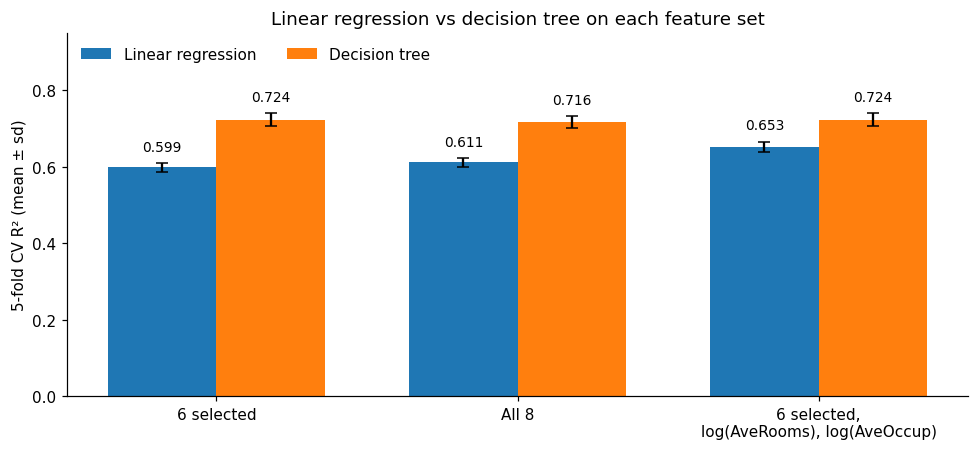

In [28]:
labels = ["6 selected", "All 8", "6 selected,\nlog(AveRooms), log(AveOccup)"]
pos = np.arange(len(runs))
width = 0.36
fig, ax = plt.subplots(figsize=(9, 4.2))
for k, (name, colour) in enumerate([("Linear regression", "tab:blue"), ("Decision tree", "tab:orange")]):
    means = [r["table"].loc[name, "CV R² mean"] for r in runs.values()]
    sds = [r["table"].loc[name, "CV R² sd"] for r in runs.values()]
    bars = ax.bar(pos + (k - 0.5) * width, means, width, yerr=sds, capsize=4, color=colour, label=name)
    ax.bar_label(bars, labels=[f"{m:.3f}" for m in means], padding=6, fontsize=9)
ax.set_xticks(pos)
ax.set_xticklabels(labels)
ax.set_ylim(0, 0.95)
ax.set_ylabel("5-fold CV R² (mean ± sd)")
ax.set_title("Linear regression vs decision tree on each feature set")
ax.legend(loc="upper left", ncol=2, frameon=False)
plt.tight_layout()
plt.show()

**Features.** I chose MedInc, HouseAge, AveRooms, AveOccup, Latitude and Longitude: the top six by mutual information, and the six with a clear reason to affect prices. AveBedrms repeats AveRooms and Population describes the size of the census area rather than the housing.

**Task 3, nonlinearity.** A tuned decision tree beats linear regression on the selected features by 0.125 $R^2$ in cross-validation (0.724 against 0.599) and by 0.15 on the test set (0.730 against 0.582), in every fold. The linear model also leaves clusters of errors on the map and predicts values above the cap and below zero. The relationship is nonlinear, mostly because of location, with smaller contributions from crowding, room counts, the age top code and the cap on house values. Income alone is close to linear.

**Task 3, all features.** The same tree on all eight features scores the same or slightly worse (0.716 CV, 0.727 test). The two dropped features carry almost no usable information, and the nonlinearity gap is the same size either way.

**Task 4, transformation.** Taking the log of AveRooms and AveOccup leaves the tree's predictions identical, because trees only use the order of each feature's values, and it raises linear regression to 0.653 (CV) and 0.640 (test). About 43% of the gap closes, but the tree still wins in every fold, so the transformed features still have a nonlinear relationship with the target. The part that remains is mostly the location surface, which no single-feature transformation can straighten.

*Numbers were produced with the library versions printed in the setup cell. Other versions of scikit-learn can give slightly different values for the tree and the mutual information estimates, but the conclusions do not depend on the third decimal.*

Use the wine recognition dataset available in scikit-learn ([https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-recognition-dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-recognition-dataset)) and perform the following:

- Load the dataset in Python or Jupyter.
- Choose four to eight features (up to you) that you think are best to predict wine type.
- Train a nonlinear classifier (for example, an SVM) and decide if your results show whether the features you selected are nonlinearly separable or not. Compare your results with training the same model on the full set of features.
- Try a single transformation of your selected features (it is up to you if the transformation is linear or nonlinear) and evaluate if your new transformed features have a nonlinear relationship with the target.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def main():
    """
    To ideally determine which features to use, we must group each of the columns
    and calculate their means and standard deviations.
    If the means of the groups are similar and the standard deviation is small then the groups barely overlap.

    THE CODE BELOW IS FOR PART 2 WHICH IS USES THE SAME FEATURE SELECTION METHOD AS PART 1, HOWEVER DIFFERENT, NON-LINEAR CLASSIFIER MODEL.
    """

    dataset = load_wine(
        as_frame=True
    )  # true changes the output from a numpy array to a pandas dataframe
    print(type(dataset))
    # print(dataset.keys())

    # pandas dataframe and feature names
    # print(dataset.feature_names)
    # print(dataset.target_names)
    # print(dataset.target)
    # print(dataset.frame)
    # print(dataset.data)
    # print(dataset.DESCR)

    # we put out the wine data in X and the targets in y
    X = dataset.data
    y = dataset.target
    print(X.shape)  # (instances, attributes)
    print(y.shape)

    print(type(dataset.frame))
    print(
        dataset.frame.groupby("target").mean()
    )  # compare the means of the groups to see if there is a signiicance
    print(
        dataset.frame.groupby("target").std()
    )  # using the mean leverage the stds to see if there is a signiicance between the groups
    means = dataset.frame.groupby("target").mean()
    stds = dataset.frame.groupby("target").std()

    mean_diff_classoneandtwo = (
        means.loc[1] - means.loc[2]
    )  # finding mean differences between classes 1 and 2 to test for significance
    avg_std_classoneandtwo = (
        (stds.loc[1] + stds.loc[2]) / 2
    )  # finding std avg between two classes (1 and 2) so it can be used to find the amount of deviations
    significant_feature_classoneandtwo = (
        mean_diff_classoneandtwo / avg_std_classoneandtwo
    )  # OD280 (2.87), color intensity (2.66), flavanoids (2.60) and hue (2.35) are most significant

    mean_diff_classzeroandtwo = (
        means.loc[0] - means.loc[2]
    )  # finding mean differences between classes 0 and 2 to test for significance
    avg_std_classzeroandtwo = (
        (stds.loc[0] + stds.loc[2]) / 2
    )  # finding std avg between two classes (0 and 2) so it can be used to find the amount of deviations
    significant_feature_classzeroandtwo = (
        mean_diff_classzeroandtwo / avg_std_classzeroandtwo
    )  # flavanoids (6.37), OD280 (4.69) and hue (3.29)

    mean_diff_classzeroandone = (
        means.loc[0] - means.loc[1]
    )  # finding mean differences between classes 0 and 1 to test for significance
    avg_std_classzeroandone = (
        (stds.loc[0] + stds.loc[1]) / 2
    )  # finding std avg between two classes (0 and 1) so it can be used to find the amount of deviations
    significant_feature_classzeroandone = (
        mean_diff_classzeroandone / avg_std_classzeroandone
    )  # proline (3.15), alcohol (2.93), and (2.26)

    print(significant_feature_classoneandtwo)
    print(significant_feature_classzeroandtwo)
    print(significant_feature_classzeroandone)

    # ideal feature picks: flavanoids, proline, hue, OD280 and alcohol
    feature_picks = [
        "flavanoids",
        "proline",
        "hue",
        "od280/od315_of_diluted_wines",
        "alcohol",
    ]
    feature_table = dataset.frame[feature_picks]
    print(feature_table)

    # NON LINEAR MODEL (SVM SVC)
    # we split the data into training and testing sets in a shuffle and then stratisfied format.
    X_train, X_test, y_train, y_test = train_test_split(
        feature_table, y, test_size=0.2, random_state=42, stratify=y
    )
    # realized that because SVM calculates distances, unscaled features like proline (500-1600)
    # would completely overpower smaller features like hue (0.5-1.7) so using standardization to make sure
    # all features contribute equally to the distance metric.
    wine_scaler = StandardScaler()
    X_train = wine_scaler.fit_transform(X_train)
    X_test = wine_scaler.transform(X_test)
    print(X_train.shape, X_test.shape)  # to verify the shapes

    # svm
    model = SVC(
        kernel="rbf", random_state=42
    )  # we use rbf kernel to make sure it is non linear
    model.fit(X_train, y_train)
    print(model.score(X_test, y_test))
    # SVMs with rbf can create curved boundaries but also straight lineS 
    # and a perfect 1.0 simply means that a valid decision boundary exists. 
    # It does not tell you whether that boundary needs to be curved or straight.
    # logistic regression in Part 1 scored 1.0 on the same features and split, so a straight boundary is enough.


    # The assignment now asks to compare your results with training the same model on the full set of features.

    # TO DO SO:
    # create a second split with 13 features instead of 5
    # then split the training set and test set
    # then train and test the model

    X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
        dataset.data, y, test_size=0.2, random_state=42, stratify=y
    )

    wine_scaler = StandardScaler()
    X_train_full = wine_scaler.fit_transform(X_train_full)
    X_test_full = wine_scaler.transform(X_test_full)
    print(X_train_full.shape, X_test_full.shape)  # to verify the shapes

    model_full = SVC(kernel="rbf", random_state=42)
    model_full.fit(X_train_full, y_train_full)
    print(model_full.score(X_test_full, y_test_full))
    # score of 0.972 which is barely any different from the 5 feature model

    # We can see both models perform about equally well, around 97 to 100%,
    # and that a single split can't distinguish them.
    # It also first looks like as if five features do as well as all 13.
    # That means the eight features dropped didn't improve the predictions once these five were in.

    # feature tranformation and residual
    # feature transformation using log, square, root and exponential

    X_transformed = pd.DataFrame()
    X_transformed["flavanoids_sq"] = feature_table["flavanoids"] ** 2
    X_transformed["proline_log"] = np.log1p(
        feature_table["proline"]
    )  # using log1p to avoid working with zeros and negative values
    X_transformed["hue_cube"] = feature_table["hue"] ** 3
    X_transformed["od280_sqrt"] = np.sqrt(feature_table["od280/od315_of_diluted_wines"])
    X_transformed["alcohol_exp"] = np.exp(feature_table["alcohol"] / 10)

    X_train_transformed, X_test_transformed, y_train_transformed, y_test_transformed = (
        train_test_split(X_transformed, y, test_size=0.2, random_state=42, stratify=y)
    )

    transformed_scaler = StandardScaler()
    X_train_transformed_scaled = transformed_scaler.fit_transform(X_train_transformed)
    X_test_transformed_scaled = transformed_scaler.transform(X_test_transformed)

    # fitting the new model with the transformed features
    model_transformed = SVC(kernel="rbf", probability=True, random_state=42)
    model_transformed.fit(X_train_transformed_scaled, y_train_transformed)

    # testing the model
    test_score = model_transformed.score(X_test_transformed_scaled, y_test_transformed)
    print(test_score)

    # residuals (difference between actual and prediction)
    test_probabilities = model_transformed.predict_proba(X_test_transformed_scaled)
    actual_class_test_proba = test_probabilities[
        np.arange(len(y_test_transformed)), y_test_transformed
    ]
    test_residuals = 1.0 - actual_class_test_proba
    print(test_residuals)

    # plotting the residuals

    plt.figure(figsize=(10, 6))
    plt.axhline(
        y=0, color="black", linestyle="--", alpha=0.5, label="Perfect Confidence Floor"
    )

    scatter = plt.scatter(
        X_test_transformed["proline_log"],
        test_residuals,
        c=y_test_transformed,
        cmap="viridis",
        edgecolors="k",
        alpha=0.8,
        s=60,
    )

    plt.xlabel("Log-Transformed Proline Content")
    plt.ylabel("Residual Error (1.0 - Predicted Probability)")
    plt.title("Residual Plot: Testing Generalizable Non Linear Separability")

    handles, _ = scatter.legend_elements()
    plt.legend(handles, dataset.target_names, title="Wine Classes")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("residual_plot.png")


"""
The model is highly confident at the far low extreme but less certain in the middle and 
high regions. While low proline values cleanly isolate class 1 with minimal error, 
the middle region (between 6.1 and 6.6) shows significant class overlap with error spikes up to 0.28. 
Surprisingly, the model never reaches perfect confidence at the high end either, 
with class 0 residuals floating between 0.01 and 0.14, including a clear outlier near 7.43. 
Furthermore, due to the SVM's probability calibration step, almost no points sit right on the zero line, 
resulting in less extreme probability estimates across the board.
"""

if __name__ == "__main__":
    main()


**Feature selection.** To ideally determine which features to use, we must group each of the columns and calculate their means and standard deviations. If the means of the groups are similar and the standard deviation is small then the groups barely overlap. Part 2 uses the same feature selection method as Part 1, however with a different, non-linear classifier model. Comparing the classes pair by pair gave: for classes 1 and 2, OD280 (2.87), color intensity (2.66), flavanoids (2.60) and hue (2.35) are most significant; for classes 0 and 2, flavanoids (6.37), OD280 (4.69) and hue (3.29); for classes 0 and 1, proline (3.15), alcohol (2.93), and color intensity (2.26). Ideal feature picks: flavanoids, proline, hue, OD280 and alcohol.

**Split and scaling.** We split the data into training and testing sets in a shuffled and then stratified format. Realized that because SVM calculates distances, unscaled features like proline (500-1600) would completely overpower smaller features like hue (0.5-1.7), so using standardization to make sure all features contribute equally to the distance metric.

**Nonlinear classifier.** We use the rbf kernel to make sure it is non linear. SVMs with rbf can create curved boundaries but also straight lines, and a perfect 1.0 simply means that a valid decision boundary exists. It does not tell you whether that boundary needs to be curved or straight. Logistic regression in Part 1 scored 1.0 on the same features and split, so a straight boundary is enough.

**Comparison with the full feature set.** The assignment asks to compare the results with training the same model on the full set of features. To do so we create a second split with 13 features instead of 5, then split the training set and test set, then train and test the model. This gives a score of 0.972 which is barely any different from the 5 feature model. We can see both models perform about equally well, around 97 to 100%, and that a single split can't distinguish them. It also first looks like as if five features do as well as all 13. That means the eight features dropped didn't improve the predictions once these five were in.

**Transformation and residuals.** Feature transformation using log, square, root and exponential, using log1p on proline to avoid working with zeros and negative values. The model is highly confident at the far low extreme but less certain in the middle and high regions. While low proline values cleanly isolate class 1 with minimal error, the middle region (between 6.1 and 6.6) shows significant class overlap with error spikes up to 0.28. Surprisingly, the model never reaches perfect confidence at the high end either, with class 0 residuals floating between 0.01 and 0.14, including a clear outlier near 7.43. Furthermore, due to the SVM's probability calibration step, almost no points sit right on the zero line, resulting in less extreme probability estimates across the board.

Discuss and analyze your results for each bullet point.